# Data retrieval

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'nursery.csv')
df

,id,parents,has_nurs,form,children,housing,finance,social,health,decision
0,0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...,...
12955,12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   parents   12960 non-null  object
 1   has_nurs  12960 non-null  object
 2   form      12960 non-null  object
 3   children  12960 non-null  object
 4   housing   12960 non-null  object
 5   finance   12960 non-null  object
 6   social    12960 non-null  object
 7   health    12960 non-null  object
 8   decision  12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB


# Data cleaning

## Removing irrelevant cols 

In [3]:
# id is irrelevant because it doesn't guide any prediction
df.drop('id', axis=1, inplace=True)

In [4]:
df

,parents,has_nurs,form,children,housing,finance,social,health,decision
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


# Data preprocessing

This dataset is purely categorical so we simpky use label encoding to make them numerical for our model

In [5]:
from sklearn.preprocessing import LabelEncoder

In [7]:
df['children'].unique()

array(['1', '2', '3', 'more'], dtype=object)

In [6]:
le = LabelEncoder()

In [9]:
cols = df.columns

for col in cols:
    df[col] = le.fit_transform(df[col])

df

,parents,has_nurs,form,children,housing,finance,social,health,decision
0,2,3,0,0,0,0,0,2,2
1,2,3,0,0,0,0,0,1,1
2,2,3,0,0,0,0,0,0,0
3,2,3,0,0,0,0,2,2,2
4,2,3,0,0,0,0,2,1,1
...,...,...,...,...,...,...,...,...,...
12955,0,4,2,3,1,1,2,1,3
12956,0,4,2,3,1,1,2,0,0
12957,0,4,2,3,1,1,1,2,3
12958,0,4,2,3,1,1,1,1,3


# Data splitting

This involves splitting the dataset into training and test using a 80:20 ratio. Also, stratefied sampling was applied to maintain the proportions from the original dataset

In [10]:
from sklearn.model_selection import train_test_split

In [13]:
y = df['decision']
X = df.drop('decision', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(10368, 8) (10368,) (2592, 8) (2592,)


In [52]:
df['decision'].value_counts()

decision
0    4320
1    4266
3    4044
4     328
2       2
Name: count, dtype: int64

# Model building

I started by setting k to be 3 annd the results were stil no good. Plotting the Line Plot indicated that the best value for k is 9. This way is much easier and less trousers

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [38]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


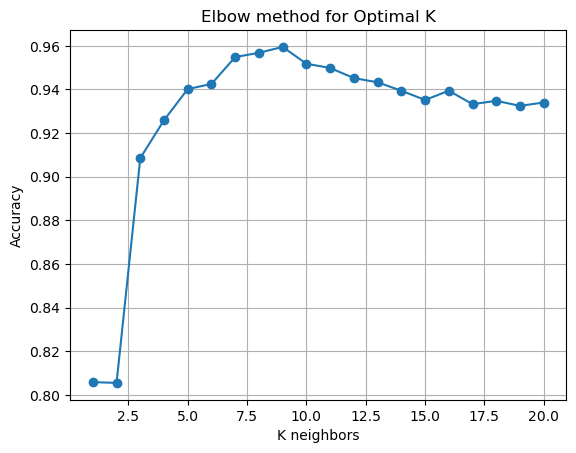

In [54]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    model.n_neighbors = k
    model.fit(X_train, y_train)
    accuracies.append(model.score(X_test, y_test))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('K neighbors')
plt.ylabel('Accuracy')
plt.title('Elbow method for Optimal K')
plt.grid(True)
plt.show()

# Evaluation

In [43]:
from sklearn.metrics import precision_score, classification_report, f1_score, recall_score, confusion_matrix

In [40]:
y_pred = model.predict(X_test)
y_pred

array([0, 3, 3, ..., 1, 3, 0], shape=(2592,))

In [41]:
acc = model.score(X_test, y_test)
pr = precision_score(y_test, y_pred, average='macro')
re = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cr = classification_report(y_test, y_pred)

In [51]:
print(f'Accuracy: {acc:.2f}')
print(f'Precision: {pr:.2f}')
print(f'Recall: {re:.2f}')
print(f'F1 score: {f1:.2f}')
print(cr)

Accuracy: 0.96
Precision: 0.97
Recall: 0.84
F1 score: 0.87
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       864
           1       0.92      0.96      0.94       853
           3       0.96      0.96      0.96       809
           4       1.00      0.42      0.60        66

    accuracy                           0.96      2592
   macro avg       0.97      0.84      0.87      2592
weighted avg       0.96      0.96      0.96      2592



Text(95.72222222222221, 0.5, 'Predicted class')

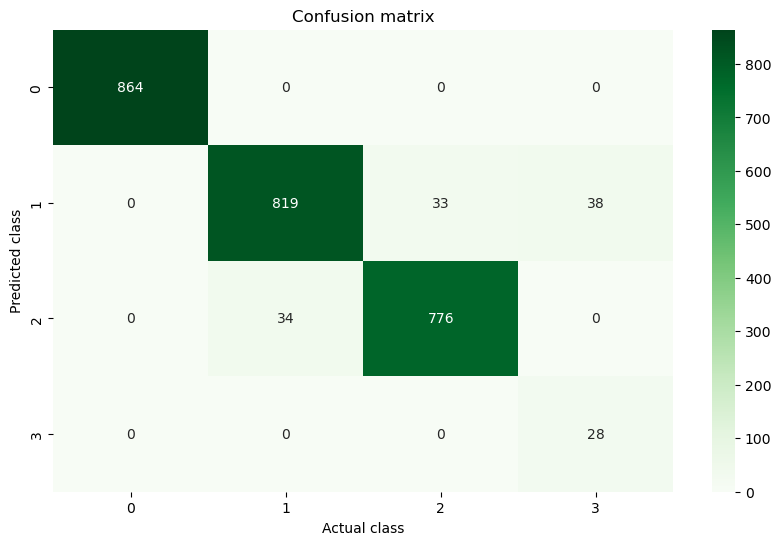

In [49]:
# Confusion matrix
cmx = confusion_matrix(y_test, y_pred)
cmx = cmx.T

plt.figure(figsize=(10,6))
sns.heatmap(cmx, annot=True, cmap='Greens', fmt='d')
plt.title('Confusion matrix')
plt.xlabel('Actual class')
plt.ylabel('Predicted class')

In [55]:
# This was to fix an issue I had pushing one other assignment to github
pip install nbformat

Note: you may need to restart the kernel to use updated packages.
